#  Setup

In [64]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from foraging import plotting
from foraging import utils
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from scipy.stats import gamma

from foraging.plotting import bp, per_block, enhanced_violinplot, titler, plot_variable_subplots
from foraging.plotting.behavior import plot_block_events, plot_pushes, plot_runlengths, plot_experiment_parameters, plot_frequencies_over_experiment, plot_experiment_overview
from foraging.utils import beliefs
from foraging.utils.data import make_df, exclusion_criteria, filter_df, display_df, get_blocks, bin_data
from foraging.utils import stats
from foraging.plotting import BOX_COLORS
from foraging.utils import BOX_LABELS, INDEX, MIN_INDEX
from functools import partial

# Filter out annoying matplotlib logs
mlogger = logging.getLogger('matplotlib')
mlogger.setLevel(logging.WARNING)

# constants
SEED = 42
RNG = np.random.default_rng(SEED)
DATA_DIR = '../data'
FIGURES_DIR = '../figures'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is given in the `Data Cleaning` notebook, as well as more details about `exclusion_criteria`.

In [11]:
df = make_df(os.path.join(DATA_DIR, 'experiments'))
df = exclusion_criteria(df)
display_df(df, ["box", "push times", "reward outcomes"])

|                                                       | box    |   push times | reward outcomes   |
|:------------------------------------------------------|:-------|-------------:|:------------------|
| ('dylan', 20211206, 2, 1, 'probability', 1, 0.1, 'M') | slow   |        3.135 | False             |
| ('dylan', 20211206, 2, 2, 'probability', 1, 0.1, 'M') | fast   |        8.465 | False             |
| ('dylan', 20211206, 2, 3, 'probability', 1, 0.1, 'M') | fast   |        9.468 | False             |
| ('dylan', 20211206, 2, 4, 'probability', 1, 0.1, 'M') | fast   |       11.667 | False             |
| ('dylan', 20211206, 2, 5, 'probability', 1, 0.1, 'M') | medium |       17.125 | False             |

In [56]:
conds = {
    'shape': 10,
    'subject': 'viktor'
}
df = filter_df(df, conds)
print(df.index.unique('kappa'))

Index([0.1, 0.04, 0.0, 0.01, 0.02, 0.03, 0.07, 0.05, 0.08], dtype='float64', name='kappa')


# Simple RL Policy
Suppose the boxes can be viewed as independent decision processes, where the decision to make is when to push. A controller that simultaneously solves this for all the boxes at a given time-- for example, if the sequence optimal pushes goes $t_2 < t_3 < t_1$, then

<Axes: title={'center': 'Distribution of push intervals when staying at box\nstay/switch = stay, kappa = 0.1'}, xlabel='prev box', ylabel='consecutive push intervals (s)'>

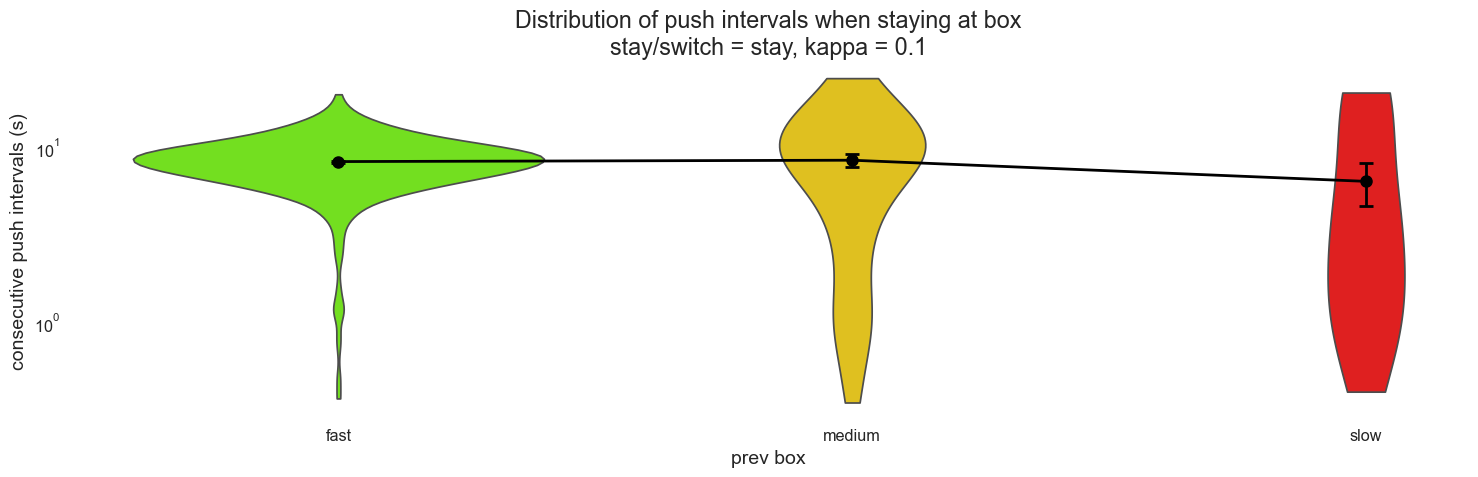

In [61]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
conds = {
    'stay/switch': 'stay',
    'kappa': 0.1
}

bp(enhanced_violinplot)(df, conds = conds, x='prev box', y='consecutive push intervals', hue = 'prev box', palette = dict(zip(BOX_LABELS, BOX_COLORS)), accumulate=True, cut=0,
                   inner=None, common_norm=True, log_scale = True, title_prefix="Distribution of push intervals when staying at box", y_unit = 's', ax=ax, legend = False)

<Axes: title={'center': 'Distribution of push intervals when staying at box\nstay/switch = switch, kappa = 0.1'}, xlabel='prev box', ylabel='consecutive push intervals (s)'>

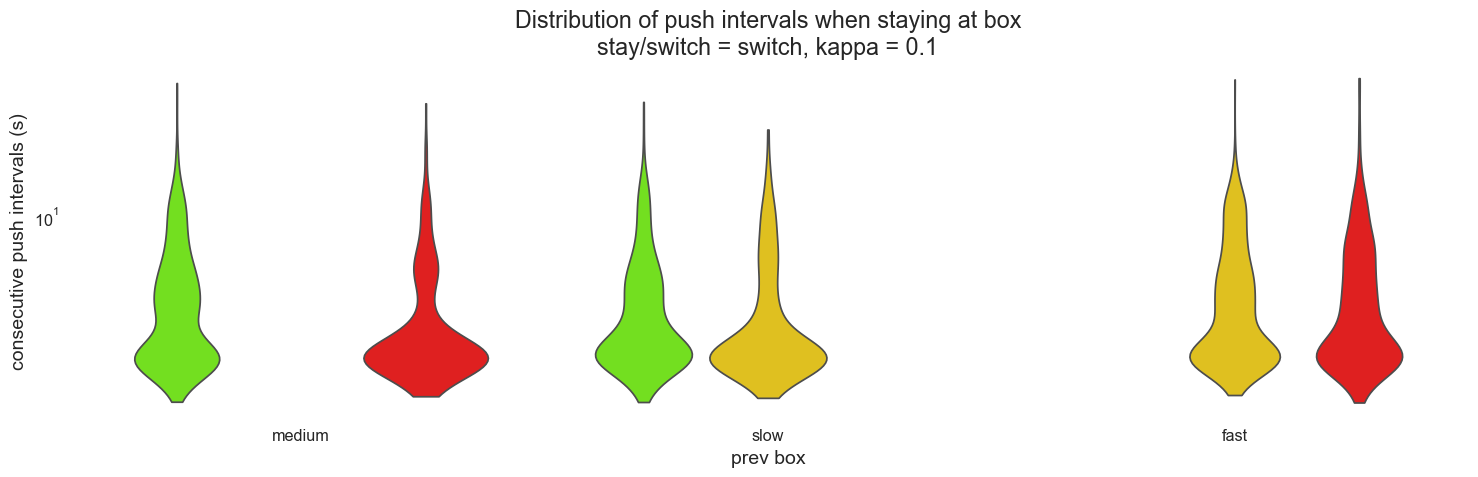

In [63]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
conds = {
    'stay/switch': 'switch',
    'kappa': 0.1
}

bp(sns.violinplot)(df, conds = conds, x='prev box', y='consecutive push intervals', hue = 'box', palette = dict(zip(BOX_LABELS, BOX_COLORS)), accumulate=True, cut=0,
                   inner=None, common_norm=True, log_scale = True, title_prefix="Distribution of push intervals when staying at box", y_unit = 's', ax=ax, legend = False)

# Hypothesis: if the data come from a Hidden Markov Model, the push intervals can be well described by an exponential distribution

In [55]:
from scipy.stats import kstest, expon
from functools import partial

# The MLE of data from an exponential distribution is 1/mean
mle_exp = 1 / df.groupby(['prev box', 'box'])['consecutive push intervals'].mean()
prev_boxes = df.dropna()['prev box'].unique()
next_boxes = df['box'].unique()
p_vals = np.zeros((len(prev_boxes), len(next_boxes)))
for i, prev_box in enumerate(prev_boxes):
    for j, next_box in enumerate(next_boxes):
        push_times = df.loc[(df['prev box'] == prev_box) & (df['box'] == next_box), 'consecutive push intervals']
        p_vals[i,j] = kstest(push_times, cdf = partial(expon.cdf, scale = mle_exp.loc[(prev_box, next_box)])).pvalue
p_vals

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 4.71888911e-233, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000]])

Single box, single decision optimal push time

Text(0, 0.5, '$Q(t) = e^{-\\gamma t}F(t)$')

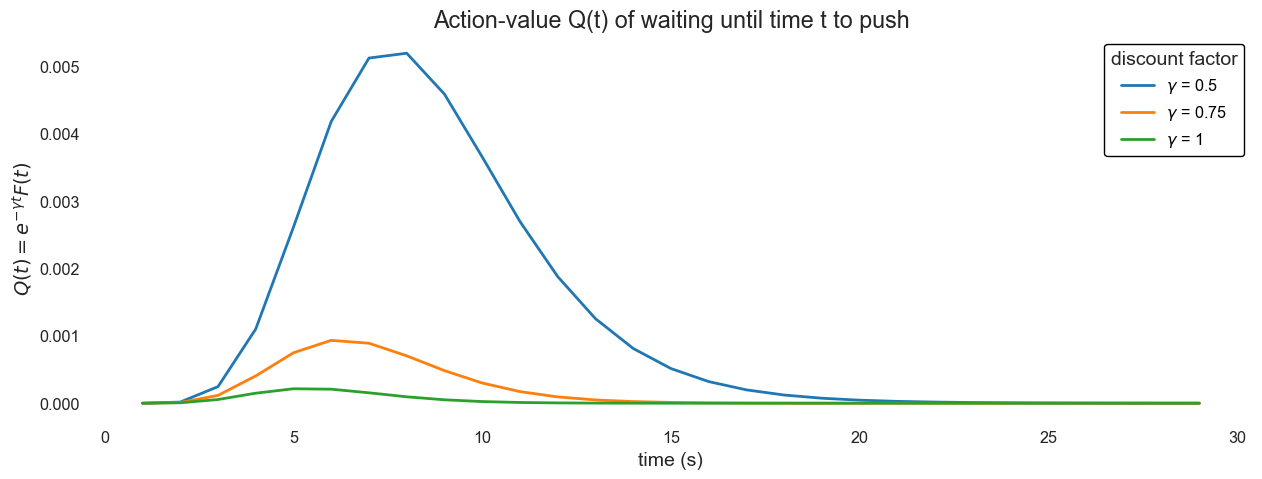

In [81]:
def q_value(discount_factor, t, schedule, alpha = 10):
    return np.exp(-discount_factor*t) * gamma.cdf(t, a = alpha, scale = schedule / alpha)

ts = np.arange(1, 30)
discounts = [0.5, 0.75, 1]
schedule = 10
for discount in discounts:
    ys = q_value(discount, ts, schedule)
    plt.plot(ts, ys, label = rf'$\gamma$ = {discount}')
plt.legend(title = 'discount factor')
plt.title(r"Action-value Q(t) of waiting until time t to push")
plt.xlabel('time (s)')
plt.ylabel(r'$Q(t) = e^{-\gamma t}F(t)$')

# Hidden Semi-Markov Model
The time between pushes are log-normal
